In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

In [4]:
rawdata = """
Date,Store_ID,SKU_Category,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales
2023-10-01,ST-001,Produce,0.80,2.50,150,110,40,0,0,0
2023-10-01,ST-001,Dairy,1.50,3.99,80,80,0,1,1,15
2023-10-01,ST-001,Bakery,1.20,4.50,60,45,15,0,0,0
2023-10-01,ST-001,Pantry,2.00,5.50,100,95,5,0,0,0
2023-10-01,ST-002,Produce,0.80,2.50,120,120,0,1,0,8
2023-10-01,ST-002,Dairy,1.50,3.99,90,75,15,0,0,0
2023-10-01,ST-002,Bakery,1.20,4.50,50,50,0,1,1,20
2023-10-01,ST-003,Produce,0.80,2.50,200,160,40,0,0,0
2023-10-02,ST-001,Produce,0.80,2.50,130,130,0,1,1,25
2023-10-02,ST-001,Dairy,1.50,3.99,100,82,18,0,0,0
"""
data = pd.read_csv(StringIO(rawdata))

In [5]:
data

,Date,Store_ID,SKU_Category,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales
0,2023-10-01,ST-001,Produce,0.8,2.50,150,110,40,0,0,0
1,2023-10-01,ST-001,Dairy,1.5,3.99,80,80,0,1,1,15
2,2023-10-01,ST-001,Bakery,1.2,4.50,60,45,15,0,0,0
3,2023-10-01,ST-001,Pantry,2.0,5.50,100,95,5,0,0,0
4,2023-10-01,ST-002,Produce,0.8,2.50,120,120,0,1,0,8
5,2023-10-01,ST-002,Dairy,1.5,3.99,90,75,15,0,0,0
6,2023-10-01,ST-002,Bakery,1.2,4.50,50,50,0,1,1,20
7,2023-10-01,ST-003,Produce,0.8,2.50,200,160,40,0,0,0
8,2023-10-02,ST-001,Produce,0.8,2.50,130,130,0,1,1,25
9,2023-10-02,ST-001,Dairy,1.5,3.99,100,82,18,0,0,0


In [6]:
data.head()

,Date,Store_ID,SKU_Category,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales
0,2023-10-01,ST-001,Produce,0.8,2.50,150,110,40,0,0,0
1,2023-10-01,ST-001,Dairy,1.5,3.99,80,80,0,1,1,15
2,2023-10-01,ST-001,Bakery,1.2,4.50,60,45,15,0,0,0
3,2023-10-01,ST-001,Pantry,2.0,5.50,100,95,5,0,0,0
4,2023-10-01,ST-002,Produce,0.8,2.50,120,120,0,1,0,8


In [7]:
data["Date"] = pd.to_datetime(data["Date"])

In [8]:
data["Day_of_Week"] = data["Date"].dt.day_name()

data[["Date","Day_of_Week"]].head()

,Date,Day_of_Week
0,2023-10-01,Sunday
1,2023-10-01,Sunday
2,2023-10-01,Sunday
3,2023-10-01,Sunday
4,2023-10-01,Sunday


In [39]:
data["Weekend_Flag"] = (data["Date"].dt.dayofweek >= 5).astype(int)

data[["Date","Weekend_Flag"]].head()

,Date,Weekend_Flag
0,2023-10-01,1
1,2023-10-01,1
2,2023-10-01,1
3,2023-10-01,1
4,2023-10-01,1


In [28]:
np.random.seed(42)

data["Temperature"] = np.random.randint(20,40,len(data))

data["Rainfall_mm"] = np.random.randint(0,50,len(data))

data["Humidity"] = np.random.randint(40,90,len(data))

data.head()

,Date,Store_ID,SKU_Category,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales,Day_of_Week,Weekend_Flag,Temperature,Rainfall_mm,Humidity,Store_City,Population_Density,Avg_Household_Income
0,2023-10-01,ST-001,Produce,0.8,2.50,150,110,40,0,0,0,Sunday,1,26,39,60,Delhi,12000,800000
1,2023-10-01,ST-001,Dairy,1.5,3.99,80,80,0,1,1,15,Sunday,1,39,23,72,Delhi,12000,800000
2,2023-10-01,ST-001,Bakery,1.2,4.50,60,45,15,0,0,0,Sunday,1,34,2,51,Delhi,12000,800000
3,2023-10-01,ST-001,Pantry,2.0,5.50,100,95,5,0,0,0,Sunday,1,30,21,61,Delhi,12000,800000
4,2023-10-01,ST-002,Produce,0.8,2.50,120,120,0,1,0,8,Sunday,1,27,1,83,Mumbai,20000,950000


In [36]:
city_map = {"ST-001":"Delhi","ST-002":"Mumbai","ST-003":"Bangalore"}

data["Store_City"] = (data["Store_ID"].map(city_map))

In [37]:
density_map = {"Delhi":12000,"Mumbai":20000,"Bangalore":4500}

data["Population_Density"] = (data["Store_City"].map(density_map))

In [38]:
income_map = {"Delhi":800000,"Mumbai":950000,"Bangalore":1000000}

data["Avg_Household_Income"] = (data["Store_City"].map(income_map))

In [14]:
data.head()

,Date,Store_ID,SKU_Category,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales,Day_of_Week,Weekend_Flag,Temperature,Rainfall_mm,Humidity,Store_City,Population_Density,Avg_Household_Income
0,2023-10-01,ST-001,Produce,0.8,2.50,150,110,40,0,0,0,Sunday,1,26,39,60,Delhi,12000,800000
1,2023-10-01,ST-001,Dairy,1.5,3.99,80,80,0,1,1,15,Sunday,1,39,23,72,Delhi,12000,800000
2,2023-10-01,ST-001,Bakery,1.2,4.50,60,45,15,0,0,0,Sunday,1,34,2,51,Delhi,12000,800000
3,2023-10-01,ST-001,Pantry,2.0,5.50,100,95,5,0,0,0,Sunday,1,30,21,61,Delhi,12000,800000
4,2023-10-01,ST-002,Produce,0.8,2.50,120,120,0,1,0,8,Sunday,1,27,1,83,Mumbai,20000,950000


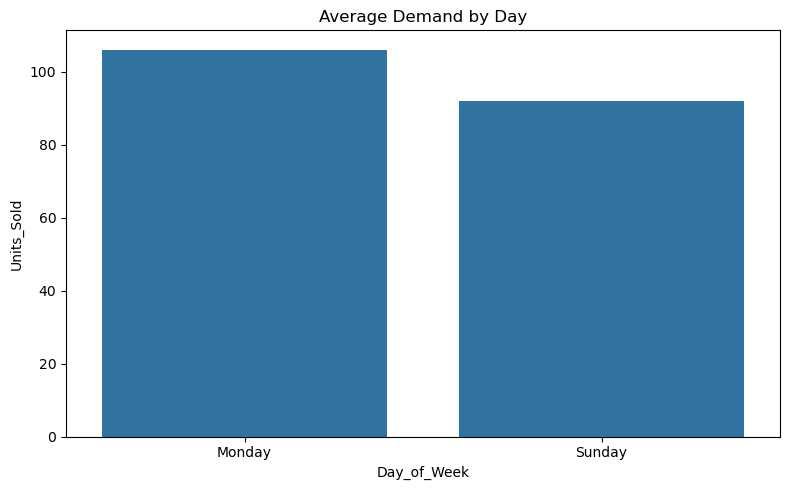

In [29]:
day_sales = (data.groupby("Day_of_Week")["Units_Sold"].mean().reset_index())

plt.figure(figsize=(8,5))

sns.barplot(data=day_sales,x="Day_of_Week",y="Units_Sold")

plt.title("Average Demand by Day")

plt.tight_layout()
plt.show()

### Analysis: Demand by Day of Week

To understand whether customer demand changes during the week, I calculated the average Units Sold for each day.
From the results:
- Sunday average demand ≈ 91 units
- Monday average demand ≈ 106 units

This shows that demand is not exactly the same every day. In the available sample, Monday demand is higher than Sunday demand.

Although the dataset sample is small, this suggests that the day of the week may influence customer purchasing behaviour. Because of this, Day_of_Week can be a useful feature for demand forecasting models.

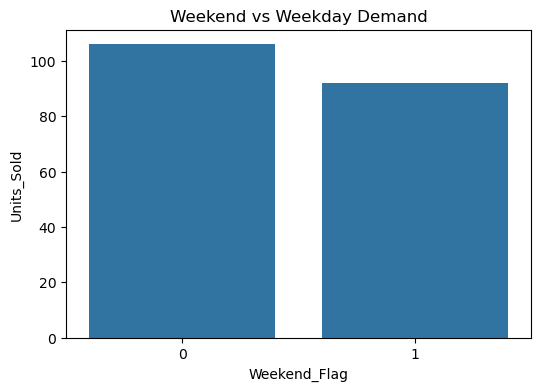

In [26]:
weekend_sales = (data.groupby("Weekend_Flag")["Units_Sold"].mean().reset_index())

plt.figure(figsize=(6,4))

sns.barplot(data=weekend_sales,x="Weekend_Flag",y="Units_Sold")

plt.title("Weekend vs Weekday Demand")

plt.show()

### Analysis: Weekend vs Weekday Demand

I created a Weekend_Flag feature to compare customer demand on weekends and weekdays.
The results show:
- Weekend demand ≈ 92 units
- Weekday demand ≈ 106 units

Based on the available data, demand appears to be slightly higher during weekdays.

This indicates that customer buying patterns may change depending on whether it is a weekday or weekend. Including this feature may help improve forecasting accuracy in future models.

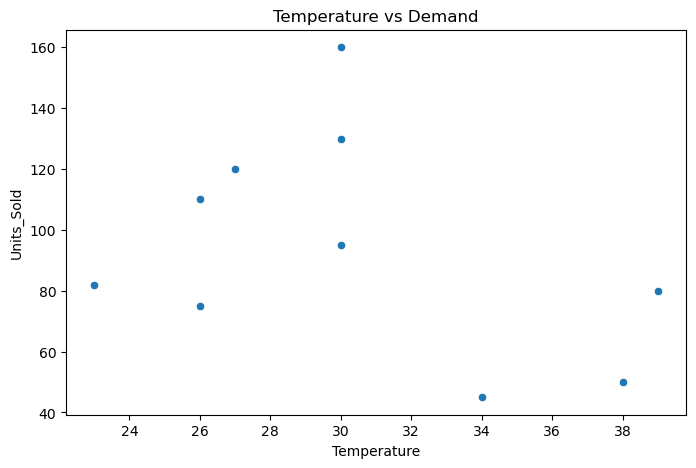

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=data,x="Temperature",y="Units_Sold")

plt.title("Temperature vs Demand")

plt.show()

### Analysis: Temperature vs Demand

Temperature is an important feature because weather conditions often influence customer demand in real-world situations.

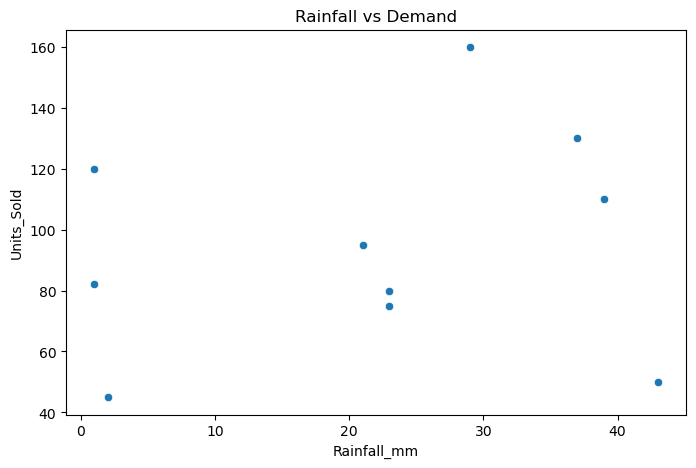

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=data,x="Rainfall_mm",y="Units_Sold")

plt.title("Rainfall vs Demand")

plt.show()

### Analysis: Rainfall vs Demand

Rainfall was added as another example of an external feature that could affect customer demand.
Rainfall is commonly used in forecasting because customers may behave differently during rainy weather, especially when using delivery services.

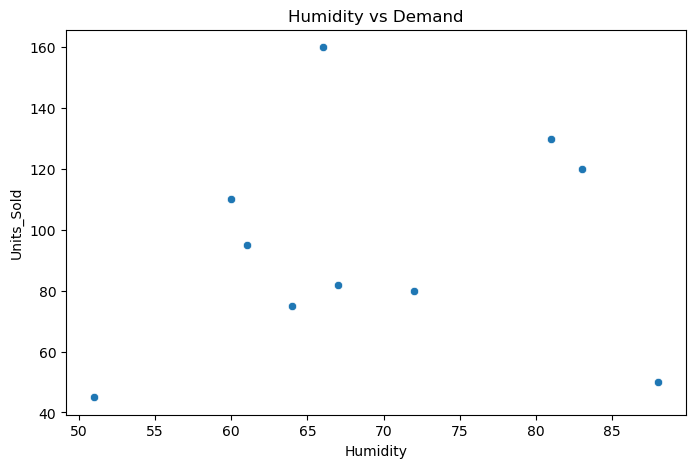

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=data,x="Humidity",y="Units_Sold")

plt.title("Humidity vs Demand")

plt.show()

### Analysis: Humidity vs Demand

Humidity was included as an additional weather-related feature because it can influence the demand for certain food categories

In [33]:
corr = data.corr(numeric_only=True)
corr

,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales,Weekend_Flag,Temperature,Rainfall_mm,Humidity,Population_Density,Avg_Household_Income
Unit_Cost,1.000000,0.898993,-0.541414,-0.524559,-0.330586,-0.280067,-0.072079,-0.258261,0.076225,0.110250,-0.229913,-0.304824,0.109981,-0.319264
Retail_Price,0.898993,1.000000,-0.732682,-0.738760,-0.381441,-0.218683,0.010433,-0.165426,0.196117,0.342970,-0.181628,-0.277829,0.186670,-0.268212
Units_Ordered,-0.541414,-0.732682,1.000000,0.944972,0.665144,-0.251870,-0.331397,-0.240164,-0.083051,-0.466892,0.205151,-0.080476,-0.606684,0.258506
Units_Sold,-0.524559,-0.738760,0.944972,1.000000,0.384253,0.007186,-0.154291,-0.009410,-0.165760,-0.386071,0.194442,0.150818,-0.500823,0.261320
Units_Spoiled,-0.330586,-0.381441,0.665144,0.384253,1.000000,-0.727183,-0.583044,-0.656267,0.143971,-0.436381,0.135130,-0.571343,-0.568957,0.133052
Stockout_Flag,-0.280067,-0.218683,-0.251870,0.007186,-0.727183,1.000000,0.801784,0.902478,-0.102062,0.522453,0.221271,0.866275,0.408133,0.101080
Peak_Hour_Stockout,-0.072079,0.010433,-0.331397,-0.154291,-0.583044,0.801784,1.000000,0.936414,-0.218218,0.702521,0.538004,0.654989,0.141569,-0.121566
Est_Lost_Sales,-0.258261,-0.165426,-0.240164,-0.009410,-0.656267,0.902478,0.936414,1.000000,-0.308835,0.543008,0.464707,0.802430,0.257693,-0.029513
Weekend_Flag,0.076225,0.196117,-0.083051,-0.165760,0.143971,-0.102062,-0.218218,-0.308835,1.000000,0.379924,0.095842,-0.213100,0.175482,0.402340
Temperature,0.110250,0.342970,-0.466892,-0.386071,-0.436381,0.522453,0.702521,0.543008,0.379924,1.000000,0.310994,0.243157,0.012972,-0.011139


## Correlation Analysis Findings

The correlation matrix was used to identify relationships between operational variables and customer demand.
Key observations include:

### 1. Units Ordered vs Units Sold
Correlation = 0.94
This is the strongest relationship in the dataset. Stores that order more inventory generally sell more products. This confirms that inventory availability strongly influences sales volume.

### 2. Stockout Flag vs Estimated Lost Sales
Correlation = 0.90
A very strong positive relationship exists between stockouts and lost sales. When products go out of stock, SwiftCart immediately loses potential revenue.

### 3. Peak Hour Stockout vs Estimated Lost Sales
Correlation = 0.94
Peak-hour stockouts show the strongest relationship with lost sales. This indicates that inventory shortages during high-demand periods have a significant financial impact.

### 4. Units Spoiled vs Stockout Flag
Correlation = -0.73
A strong negative relationship exists between spoilage and stockouts. Stores that overstock tend to experience more spoilage but fewer stockouts, while stores that understock experience the opposite problem.

This highlights the core inventory balancing challenge faced by SwiftCart.

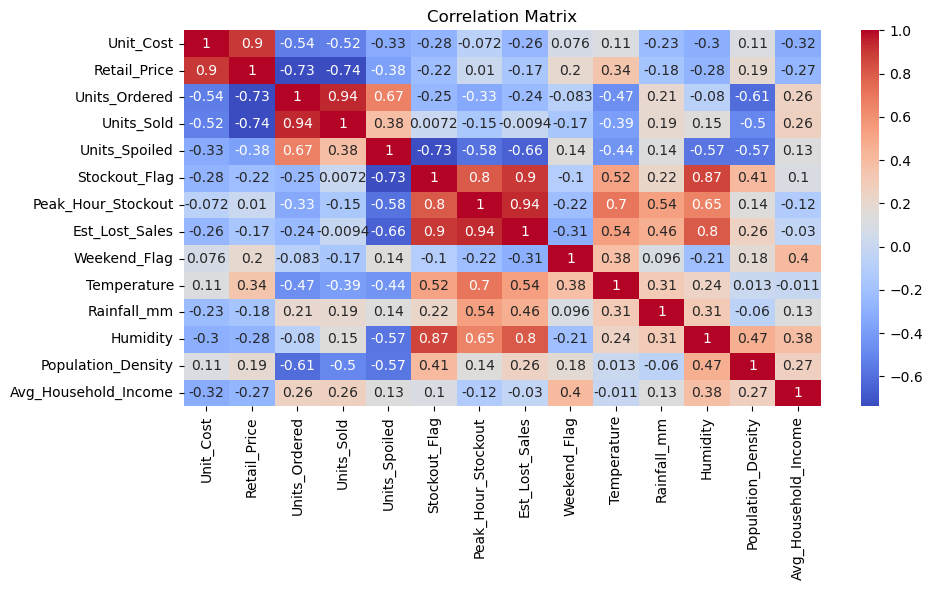

In [34]:
plt.figure(figsize=(10,6))

sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

### Heatmap Interpretation

The strongest positive relationships are observed between:
- Units Ordered and Units Sold
- Stockout Flag and Estimated Lost Sales
- Peak Hour Stockout and Estimated Lost Sales

These relationships suggest that both inventory availability and stockout events are critical drivers of business performance.

The heatmap also shows that multiple variables interact simultaneously, supporting the need for a multi-feature forecasting model rather than relying solely on historical sales.

In [35]:
encoded_data = pd.get_dummies(data,columns=["SKU_Category","Day_of_Week","Store_City"])

encoded_data.head()

,Date,Store_ID,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales,...,Avg_Household_Income,SKU_Category_Bakery,SKU_Category_Dairy,SKU_Category_Pantry,SKU_Category_Produce,Day_of_Week_Monday,Day_of_Week_Sunday,Store_City_Bangalore,Store_City_Delhi,Store_City_Mumbai
0,2023-10-01,ST-001,0.8,2.50,150,110,40,0,0,0,...,800000,False,False,False,True,False,True,False,True,False
1,2023-10-01,ST-001,1.5,3.99,80,80,0,1,1,15,...,800000,False,True,False,False,False,True,False,True,False
2,2023-10-01,ST-001,1.2,4.50,60,45,15,0,0,0,...,800000,True,False,False,False,False,True,False,True,False
3,2023-10-01,ST-001,2.0,5.50,100,95,5,0,0,0,...,800000,False,False,True,False,False,True,False,True,False
4,2023-10-01,ST-002,0.8,2.50,120,120,0,1,0,8,...,950000,False,False,False,True,False,True,False,False,True


In [23]:
encoded_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  10 non-null     datetime64[ns]
 1   Store_ID              10 non-null     object        
 2   Unit_Cost             10 non-null     float64       
 3   Retail_Price          10 non-null     float64       
 4   Units_Ordered         10 non-null     int64         
 5   Units_Sold            10 non-null     int64         
 6   Units_Spoiled         10 non-null     int64         
 7   Stockout_Flag         10 non-null     int64         
 8   Peak_Hour_Stockout    10 non-null     int64         
 9   Est_Lost_Sales        10 non-null     int64         
 10  Weekend_Flag          10 non-null     int64         
 11  Temperature           10 non-null     int32         
 12  Rainfall_mm           10 non-null     int32         
 13  Humidity              1

In [24]:
encoded_data.to_csv("week2_feature_engineered_data.csv",index=False)

### Final Feature Schema

Operational Features:
- Units Ordered
- Units Sold
- Units Spoiled
- Stockout Flag
- Peak Hour Stockout
- Estimated Lost Sales

Temporal Features:
- Day of Week
- Weekend Flag

Environmental Features:
- Temperature
- Rainfall
- Humidity

Location Features:
- Store City
- Population Density
- Average Household Income

## Business Recommendation

Based on this analysis, I believe that historical sales data alone may not be enough to accurately predict future demand.
Several important factors influence customer demand:
1. Demand varies across days of the week.
2. Stockouts are strongly associated with lost revenue.
3. Peak-hour stockouts create the greatest business impact.
4. Inventory decisions involve a trade-off between spoilage and stockouts.
5. External variables such as weather and location characteristics may further improve forecasting accuracy.

SwiftCart should expand its data collection strategy to include weather conditions, local demographics, and seasonal patterns. These variables can help forecasting models anticipate demand changes before they occur.

## Conclusion

In this week's analysis, I focused on feature engineering and explored variables that could help explain customer demand beyond historical sales data.I created new temporal features, examined relationships between variables using correlation analysis, and prepared a structured dataset for future modeling.

The analysis showed that inventory levels, stockout events, and time-based features all have useful information that may help improve forecasting accuracy.The final feature-engineered dataset will be used in Week 3 to build a demand forecasting model and further investigate how these variables can help reduce wastage and lost sales at SwiftCart.